* Resume Screening & Ranking System (ML Project)
* Tools: Python, spaCy, NLTK, Scikit-learn, Pandas
* Dataset: resume.csv (column: 'resume_text')

Step 0: Install required packages (run once)

In [1]:
!pip install pandas numpy spacy nltk scikit-learn pdfplumber matplotlib seaborn
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 5.1 MB/s eta 0:00:03
     ---- ----------------------------------- 1.6/12.8 MB 5.1 MB/s eta 0:00:03
     -------- ------------------------------- 2.6/12.8 MB 5.4 MB/s eta 0:00:02
     ----------- ---------------------------- 3.7/12.8 MB 5.0 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 5.0 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 4.9 MB/s eta 0:00:02
     ----------------- ---------------------- 5.5/12.8 MB 4.3 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.8 MB 3.9 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 3.6 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 3.9 MB/s eta 0:00:02
     --------------------------- ------------ 8.9/12.8 MB 4.0 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Step 1: Import Libraries

In [2]:
# Operating system & file handling
import os       # For interacting with the file system (paths, directories, etc.)
import joblib
import nltk    # Natural Language Toolkit for text processing and analysis

# Text processing
import re       # Regular expressions for text cleaning and pattern matching
import spacy    # NLP library for tokenization, lemmatization, and linguistic features
from nltk.corpus import stopwords  # For removing common words like 'the', 'is', etc.

# Data handling
import pandas as pd  # DataFrames for structured data
import numpy as np   # Numerical operations, arrays, and mathematical computations

# Machine Learning / NLP
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text to TF-IDF feature vectors
from sklearn.metrics.pairwise import cosine_similarity        # Measure similarity between text vectors

# Visualization
import matplotlib.pyplot as plt  # Plotting graphs and charts
import seaborn as sns            # Advanced visualization with themes and color palettes

from nltk.tokenize import word_tokenize # Tokenize text into individual words
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\97798\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\97798\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

1.1 Load spaCy NLP model & NLTK stopwords

In [3]:
# Load the small English model from spaCy
nlp = spacy.load('en_core_web_sm')
# Load English stopwords from NLTK
stop_words = set(stopwords.words('english'))

In [4]:
#Usage example
text = "This is an example sentence."
doc = nlp(text)
filtered_words = [token.text for token in doc if token.text.lower() not in stop_words]
print(filtered_words)  # ['example', 'sentence', '.']

['example', 'sentence', '.']


Step 2. Load Dataset

In [5]:
df = pd.read_csv("../dataset/resume.csv")
print("Dataset Preview:\n", df.head()) # Display the first few rows of the dataset to understand its structure and content
df['Resume_str'] = df['Resume_str'].astype(str) # Ensure that the 'resume_str' column is treated as text for processing 

Dataset Preview:
          ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  


Step 3: Preprocess Resume Text

In [18]:
import re

def preprocess(text):
    """
    Lightweight preprocessing for resume text.

    Steps performed:
    1. Converts input to string (avoids NaN errors)
    2. Converts text to lowercase
    3. Removes numbers
    4. Removes special characters
    5. Removes extra spaces

    This version avoids spaCy for speed and low memory usage.
    """

    # 1. Ensure input is string
    text = str(text)

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # 4. Remove special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing to DataFrame
df['cleaned_resume'] = df['Resume_str'].astype(str).apply(preprocess)

print("Preprocessing complete. Sample cleaned resume:\n")
print(df['cleaned_resume'].iloc[0])

Preprocessing complete. Sample cleaned resume:

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance ass

3.1 Resume Category distribution

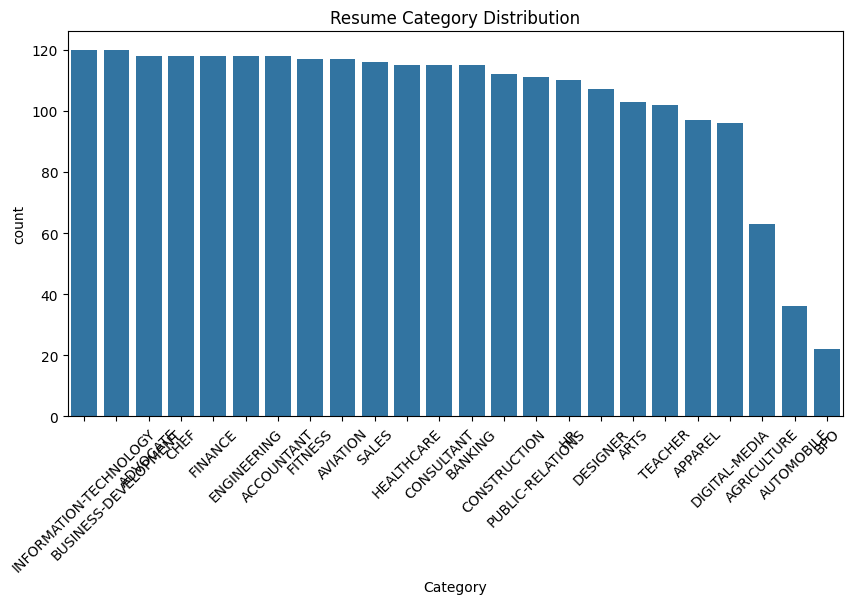

In [7]:
# Read the Resume dataset from the CSV file
# "../dataset/" means go one folder back and enter the "dataset" folder
df = pd.read_csv("../dataset/Resume.csv")

# Create a figure (plotting area) with width=10 inches and height=5 inches
plt.figure(figsize=(10,5))

# Create a count plot to show how many resumes belong to each category
# data=df → use the DataFrame
# x='Category' → plot counts of the 'Category' column
# order=... → sort categories by frequency (highest first)
sns.countplot(
    data=df,
    x='Category',
    order=df['Category'].value_counts().index
)

# Rotate x-axis labels by 45 degrees so long category names don't overlap
plt.xticks(rotation=45)

# Add a title to the plot
plt.title("Resume Category Distribution")

plt.savefig("../plots/resume_category_distribution.png")  # Save the plot as a PNG file in the plots directory
# Display the final plot
plt.show()

3.2 Resume Length Distribution

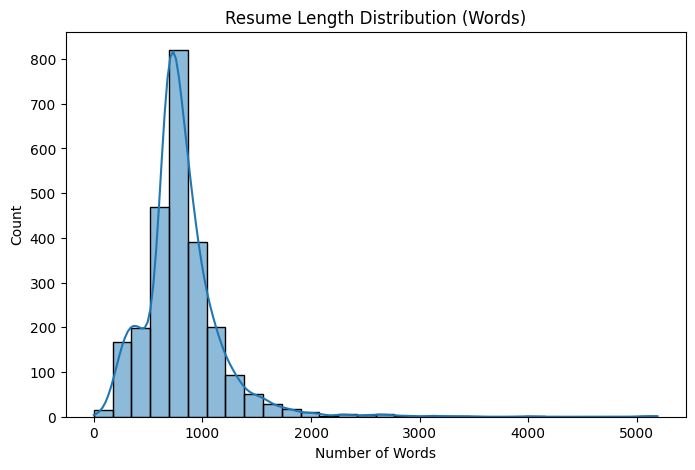

In [8]:
# Create a new column 'resume_length' For each resume in 'Resume_str':
# 1. Convert it to string (to avoid errors if NaN exists)
# 2. Split text into words
# 3. Count number of words using len()
df['resume_length'] = df['Resume_str'].apply(lambda x: len(str(x).split()))

# Create a plotting area with width=8 and height=5
plt.figure(figsize=(8,5))

# Plot histogram of resume lengths
# bins=30 → divide data into 30 bars (groups)
# kde=True → adds smooth density curve to see distribution shape
sns.histplot(df['resume_length'], bins=30, kde=True)

# Add title
plt.title("Resume Length Distribution (Words)")

# Label x-axis
plt.xlabel("Number of Words")

plt.savefig("../plots/resume_length_distribution.png")  # Save the plot as a PNG file in the plots directory
# Display the plot
plt.show()

3.3 Resume length by job category

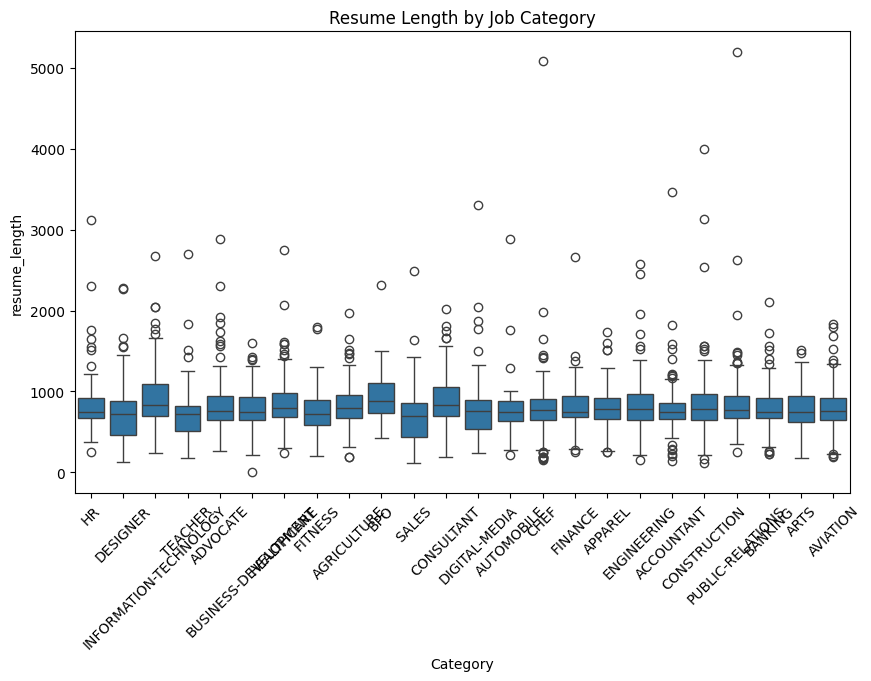

In [9]:
# Create figure with width=10 and height=6
plt.figure(figsize=(10,6))

# Create a boxplot:
# x='Category' → job category on x-axis
# y='resume_length' → word count on y-axis
# This shows distribution of resume lengths per category
sns.boxplot(data=df, x='Category', y='resume_length')

# Rotate category names to avoid overlapping text
plt.xticks(rotation=45)

# Add plot title
plt.title("Resume Length by Job Category")

plt.savefig("../plots/resume_length_by_category.png")  # Save the plot as a PNG file in the plots directory
# Display the plot
plt.show()

3.4 Common words in resumes

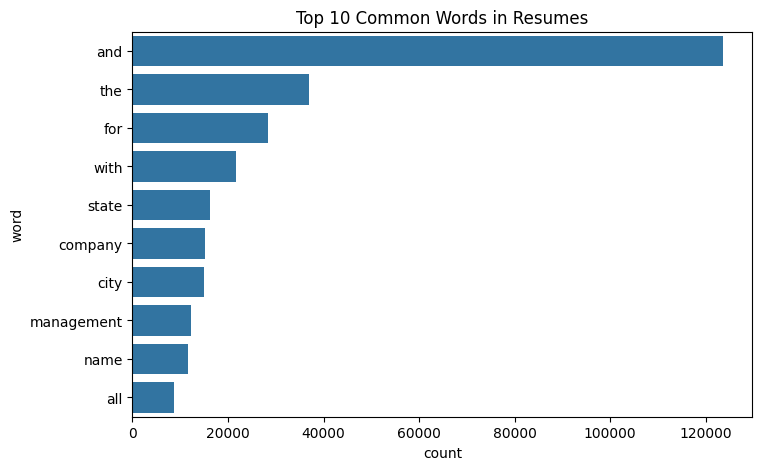

In [10]:
from collections import Counter  # For counting occurrences of words efficiently
import re

# Initialize a Counter to keep track of word frequencies
counter = Counter()

# Loop through each resume in the DataFrame
# We process one resume at a time to avoid MemoryError with large datasets
for text in df['Resume_str'].astype(str):  # Convert each entry to string just in case
    # Use regex to extract words with at least 3 letters (common practice to ignore 'a', 'an', 'in', etc.)
    # \b = word boundary, [a-z]{3,} = sequences of 3+ lowercase letters
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())  # Convert text to lowercase for uniformity
    # Update the counter with the words from this resume
    counter.update(words)

# Get top 10 most common words across all resumes
common_words = counter.most_common(10)# Returns a list of tuples (word, count)

# Convert the result into a pandas DataFrame for easier plotting
word_df = pd.DataFrame(common_words, columns=['word','count'])

# Plotting the top 10 common words
plt.figure(figsize=(8,5))
sns.barplot(data=word_df, x='count', y='word')
plt.title("Top 10 Common Words in Resumes")
plt.savefig("../plots/top_common_words.png")  # Save the plot as a PNG file in the plots directory
plt.show()

Step 4: Automatic Skill Extraction Using keyword matching

In [11]:

# Fast & Memory-Safe Skill Extraction (Keyword Only)

import pandas as pd
import re

#  1: Define the skill list

# These are the skills we want to detect in resumes.
# The system can only detect skills that exist in this list.
SKILLS = [
    "python", "java", "machine learning", "nlp", "sql", "excel",
    "tensorflow", "pytorch", "data analysis", "data science",
    "project management", "leadership"
]

#  2: Create ONE combined regex pattern

# Why combine?
# Instead of looping through each skill separately,
# we search once using a single optimized regex.
#
# \b ensures exact word matching (so "sql" != "mysql")
# re.IGNORECASE allows matching Python, PYTHON, python
pattern = re.compile(
    r"\b(" + "|".join(map(re.escape, SKILLS)) + r")\b",
    re.IGNORECASE
)

#  3: Skill extraction function

def extract_skills(text):
    """
    Extract skills using keyword matching only.

    - Searches resume text for predefined skills
    - Returns unique skills
    - Case-insensitive
    """

    # Find all matches in text
    matches = pattern.findall(text)

    # Convert to lowercase + remove duplicates
    return list(set(match.lower() for match in matches))

#  4: Apply to DataFrame
# Ensure text column has no NaN values
df['skills_found'] = df['Resume_str'].astype(str).apply(extract_skills)

#  5: Example output
print("\nSkills Found Example:\n", df['skills_found'].iloc[0])


Skills Found Example:
 ['data analysis', 'leadership']


In [12]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'resume_length',
       'skills_found'],
      dtype='str')


Step 5: Experience extraction(years)

In [13]:
import re  # Import regular expression module for pattern matching

def extract_experience(text):
    """
    Extracts years of experience from resume text.

    Looks for patterns like:
    - 3 years
    - 5+ years
    - 2-year
    - 4 yrs
    - 7 yr

    Returns:
        Maximum number of years found.
        Returns 0 if no experience pattern is detected.
    """

    # Regex pattern explanation:
    # (\d+)        → Capture one or more digits (e.g., 3, 10, 15)
    # \+?          → Optional "+" sign (e.g., 5+ years)
    # \s?          → Optional space
    # [-]?         → Optional hyphen (e.g., 3-year)
    # \s?          → Optional space again
    # (year|years|yr|yrs) → Match different variations of "year"
    pattern = r'(\d+)\+?\s?[-]?\s?(year|years|yr|yrs)'

    # Find all matches in lowercase text (case-insensitive search)
    matches = re.findall(pattern, text.lower())

    # Extract only the numeric part from matches and convert to integers
    # Each match looks like ('3', 'years'), so we take the first element
    years = [int(m[0]) for m in matches]

    # Return the maximum experience found
    # If no matches exist, return 0
    return max(years) if years else 0

# Apply the function to each resume in the DataFrame
# Creates a new column called 'experience_years'
df['experience_years'] = df['Resume_str'].apply(extract_experience)

Step 7: TF-IDF Vectorizer & Job description Similarity

In [14]:
vectorizer_path = "../models/resume_vectorizer.pkl"  
if os.path.exists(vectorizer_path):  
    vectorizer = joblib.load(vectorizer_path)  
    print("Vectorizer loaded from file.")  
else:  
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)  
    vectorizer.fit(df['cleaned_resume'])  
    joblib.dump(vectorizer, vectorizer_path)  
    print("Vectorizer trained and saved.")  

job_description = """
We are looking for a Data Scientist with strong Python, Machine Learning, NLP, SQL,
Data Analysis, and excellent Communication skills, with 3+ years of experience.
"""
clean_job = preprocess(job_description)  

# Extract required skills from job description dynamically  
job_skills = extract_skills(clean_job)  
job_exp_pattern = re.findall(r'(\d+)\+?\s?(years|yrs)', job_description.lower())  
min_exp_required = int(job_exp_pattern[0][0]) if job_exp_pattern else 0  

print("Job Skills:", job_skills)
print("Minimum Experience Required:", min_exp_required)


Vectorizer loaded from file.
Job Skills: ['python', 'nlp', 'data analysis', 'sql', 'machine learning']
Minimum Experience Required: 3


Step 8: Skill Matching Score & Missing Skills

In [15]:
def match_score(res_skills, job_skills):
    """
    Compute the percentage of job skills that the resume has.
    - res_skills: list of skills extracted from resume
    - job_skills: list of skills required in job description
    Returns a score in percentage (0-100)
    """
    matched = set(res_skills).intersection(set(job_skills))
    return round(len(matched)/len(job_skills)*100, 2) if len(job_skills)>0 else 0

df['skill_match_score'] = df['skills_found'].apply(lambda x: match_score(x, job_skills))  

# Missing skills dynamically per job description  
df['missing_skills'] = df['skills_found'].apply(lambda x: list(set(job_skills) - set(x)))  

# Example output
print(df[['skills_found', 'skill_match_score']].head())

                              skills_found  skill_match_score
0              [data analysis, leadership]               20.0
1                     [project management]                0.0
2  [excel, project management, leadership]                0.0
3                                  [excel]                0.0
4  [excel, project management, leadership]                0.0


Step 9: Experience Score

In [16]:
def experience_score(candidate_exp, required_exp):
    """
    Compute experience match as a percentage.

    - candidate_exp: years of experience extracted from resume
    - required_exp: minimum years of experience from job description

    Returns:
    - 0 to 100 score
    - Capped at 100% if candidate has equal or more experience than required
    """
    if required_exp > 0:
        score = min(candidate_exp / required_exp, 1) * 100  # Normalize to 0-100
    else:
        score = 100  # If no requirement, full score
    return round(score, 2)

# Apply function to all resumes
df['experience_score'] = df['experience_years'].apply(lambda x: experience_score(x, min_exp_required))

# Example output
print(df[['experience_years', 'experience_score']].head())

   experience_years  experience_score
0                15             100.0
1                 0               0.0
2                20             100.0
3                20             100.0
4                 0               0.0


Step 10: TF-IDF Similarity Score

In [19]:
resume_vectors = vectorizer.transform(df['cleaned_resume'])  
job_vector = vectorizer.transform([clean_job])  
df['tfidf_similarity_score'] = cosine_similarity(resume_vectors, job_vector).flatten() * 100  

 Step 10: Overall Fit Score(Weighted)

In [20]:

# Weights: skills 50%, experience 30%, TF-IDF 20%
df['overall_fit_score'] = (
    0.5*df['skill_match_score'] +
    0.3*df['experience_score'] +
    0.2*df['tfidf_similarity_score']
).round(2)

#  Sort candidates by overall fit
df_sorted = df.sort_values(by='overall_fit_score', ascending=False).reset_index(drop=True)

# Display top candidates
print(df_sorted[['experience_years', 'experience_score', 'skill_match_score', 'overall_fit_score']].head())

   experience_years  experience_score  skill_match_score  overall_fit_score
0                 3             100.0               80.0              74.95
1                 6             100.0               80.0              74.67
2                 6             100.0               80.0              74.10
3                21             100.0               40.0              53.46
4                 5             100.0               40.0              53.45


Step 13. Candidate Ranking

In [21]:
# Sort candidates by final_score descending
df_sorted = df.sort_values(by='overall_fit_score', ascending=False).reset_index(drop=True)
df_sorted['rank'] = df_sorted.index + 1
# Display top 10 candidates with correct columns
print(df_sorted[['Category', 'skills_found', 'experience_years', 'overall_fit_score', 'missing_skills']].head(10))

               Category                                       skills_found  \
0           ENGINEERING     [data analysis, python, sql, machine learning]   
1            CONSULTANT  [python, data analysis, sql, machine learning,...   
2            AUTOMOBILE  [python, data analysis, sql, excel, machine le...   
3                 SALES           [data analysis, excel, machine learning]   
4           AGRICULTURE  [python, sql, project management, leadership, ...   
5               BANKING                               [data analysis, sql]   
6           ENGINEERING  [data analysis, sql, project management, leade...   
7            AUTOMOBILE     [data analysis, sql, project management, java]   
8  BUSINESS-DEVELOPMENT  [python, sql, excel, project management, java,...   
9               FITNESS           [python, project management, excel, sql]   

   experience_years  overall_fit_score                          missing_skills  
0                 3              74.95                      

Step 11. Visualize Top candidates

C:\Users\97798\AppData\Local\Temp\ipykernel_22112\338047128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


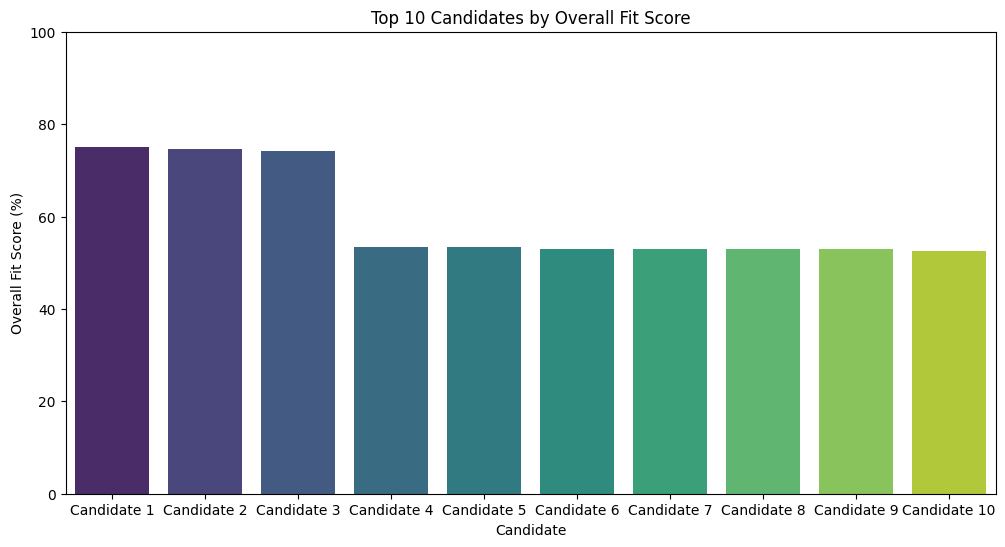

In [22]:
top_n = 10
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_sorted.head(top_n),
    x=df_sorted.head(top_n).index,
    y='overall_fit_score',
    palette='viridis'
)
plt.xticks(ticks=range(top_n), labels=[f"Candidate {i+1}" for i in range(top_n)])
plt.xlabel("Candidate")
plt.ylabel("Overall Fit Score (%)")
plt.title(f"Top {top_n} Candidates by Overall Fit Score")
plt.ylim(0, 100)
plt.savefig("../plots/top_candidates_fit_score.png")  # Save the plot as a PNG file in the plots directory
plt.show()


Step 12. Skill gap analysis

In [23]:
required_skills = ["python", "nlp", "machine learning"]

def missing_skills(skills):
    return [s for s in required_skills if s not in skills]

df["missing_skills"] = df["skills_found"].apply(missing_skills)

print("\nTop Candidate Skill Gaps:")
print(df[["skills_found", "missing_skills"]].head())



Top Candidate Skill Gaps:
                              skills_found                   missing_skills
0              [data analysis, leadership]  [python, nlp, machine learning]
1                     [project management]  [python, nlp, machine learning]
2  [excel, project management, leadership]  [python, nlp, machine learning]
3                                  [excel]  [python, nlp, machine learning]
4  [excel, project management, leadership]  [python, nlp, machine learning]


Step 13. Additional Scoring: Simple TF-IDF + Skill Coverage

In [24]:
# Transform resumes and job description using the existing vectorizer
resume_vectors = vectorizer.transform(df['cleaned_resume'])
job_vector = vectorizer.transform([clean_job])

# 1 TF-IDF similarity score (0-100 scale)
df['match_score'] = cosine_similarity(resume_vectors, job_vector).flatten() * 100

# 2 Simple skill coverage score (percentage of job skills matched)
df['skill_score_simple'] = df['skills_found'].apply(
    lambda x: len(set(x).intersection(set(job_skills))) / len(job_skills) * 100 if job_skills else 0
)

# 3️ Simple missing skills for reference
df['missing_skills_simple'] = df['skills_found'].apply(
    lambda x: list(set(job_skills) - set(x))
)

# 4️ Optional: Display top 10 candidates with both your original and the new simple scores
print(df[['skills_found', 'skill_match_score', 'skill_score_simple', 
          'experience_years', 'experience_score', 'match_score', 'missing_skills_simple']].head(10))

                              skills_found  skill_match_score  \
0              [data analysis, leadership]               20.0   
1                     [project management]                0.0   
2  [excel, project management, leadership]                0.0   
3                                  [excel]                0.0   
4  [excel, project management, leadership]                0.0   
5                                  [excel]                0.0   
6         [project management, leadership]                0.0   
7                     [project management]                0.0   
8  [excel, project management, leadership]                0.0   
9                                       []                0.0   

   skill_score_simple  experience_years  experience_score  match_score  \
0                20.0                15             100.0     8.549024   
1                 0.0                 0               0.0     5.304730   
2                 0.0                20             100.0     

C:\Users\97798\AppData\Local\Temp\ipykernel_22112\3463046213.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


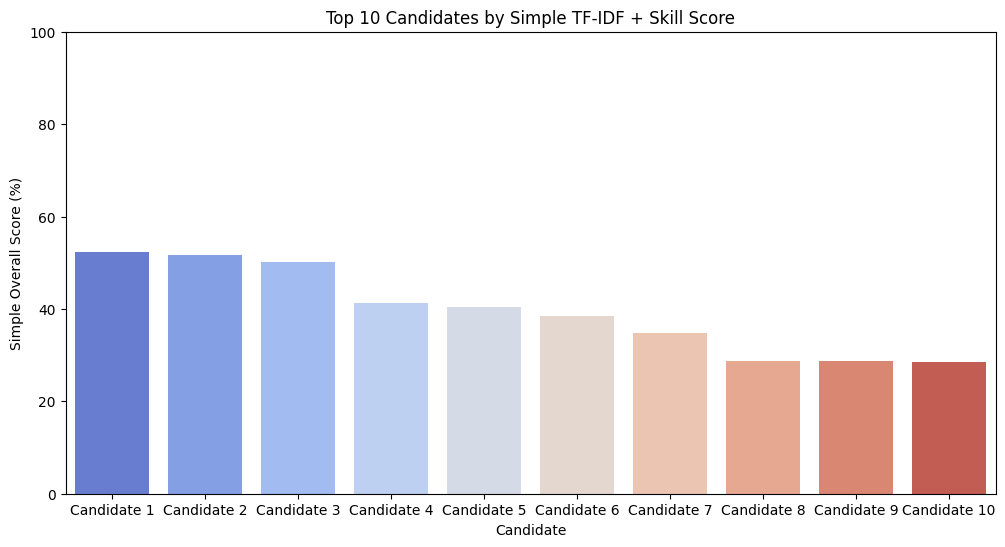

,skills_found,skill_score_simple,match_score,simple_overall_score,missing_skills_simple
0,"[data analysis, python, sql, machine learning]",80.0,24.727811,52.36,[nlp]
1,"[python, data analysis, sql, machine learning,...",80.0,23.351815,51.68,[nlp]
2,"[python, data analysis, sql, excel, machine le...",80.0,20.518130,50.26,[nlp]
3,"[python, data analysis, sql, excel, data scien...",60.0,22.740221,41.37,"[nlp, machine learning]"
4,"[python, data analysis, sql, excel, project ma...",60.0,20.856960,40.43,"[nlp, machine learning]"
5,"[python, sql, machine learning]",60.0,17.065580,38.53,"[data analysis, nlp]"
6,"[python, sql, machine learning, leadership, te...",60.0,9.578017,34.79,"[data analysis, nlp]"
7,"[data analysis, excel, machine learning]",40.0,17.281027,28.64,"[python, sql, nlp]"
8,"[python, sql, project management, leadership, ...",40.0,17.235145,28.62,"[data analysis, nlp, machine learning]"
9,"[data analysis, sql]",40.0,17.125383,28.56,"[python, nlp, machine learning]"


In [25]:
# Visualization: Simple TF-IDF + Skill Score
top_n = 10  # number of top candidates to show

# Sort by simple combined score (average of match_score + skill_score_simple)
df['simple_overall_score'] = ((df['match_score'] + df['skill_score_simple']) / 2).round(2)
df_simple_sorted = df.sort_values(by='simple_overall_score', ascending=False).reset_index(drop=True)

# Plot top N candidates
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_simple_sorted.head(top_n),
    x=df_simple_sorted.head(top_n).index,
    y='simple_overall_score',
    palette='coolwarm'
)

plt.xticks(ticks=range(top_n), labels=[f"Candidate {i+1}" for i in range(top_n)])
plt.xlabel("Candidate")
plt.ylabel("Simple Overall Score (%)")
plt.title(f"Top {top_n} Candidates by Simple TF-IDF + Skill Score")
plt.ylim(0, 100)
plt.savefig("../plots/top_candidates_simple_score.png")  # Save the plot as a PNG file in the plots directory
plt.show()

# Optional: show top candidates with key info
df_simple_sorted.head(top_n)[['skills_found', 'skill_score_simple', 'match_score', 'simple_overall_score', 'missing_skills_simple']]

Step 13. Export Results

In [ ]:
df_sorted.to_csv('../exports/enhanced_resume_ranking.csv', index=False)
df_sorted.head(50).to_csv('../exports/top_candidates.csv', index=False)
print("Ranking and top candidates exported successfully.")

Ranking and top candidates exported successfully.
